# P9 – Neural Architecture Search com Metaheurísticas

## Equipe

- Rayane Araújo
- Júlia Júnior
- Marcelo Soares
- João Pedro
- João Arthur

## Objetivo

Este projeto implementa uma abordagem de Neural Architecture Search (NAS) para classificação de dígitos manuscritos do dataset MNIST.

Serão comparadas três estratégias de busca:

1. Algoritmo Genético (AG)
2. Population-Based Incremental Learning (PBIL)
3. Optuna (TPE)

O Optuna representa o diferencial D3 da proposta, atuando como mecanismo de Hyperparameter Optimization (HPO).

As arquiteturas serão avaliadas segundo:

- Acurácia
- Número de parâmetros
- Tempo de inferência

# 1. Importação das Bibliotecas

Nesta etapa importamos as bibliotecas necessárias para a construção do sistema NAS.

Utilizamos:

- PyTorch para construção das CNNs;
- Torchvision para carregar o dataset MNIST;
- NumPy para operações matemáticas;
- Pandas para análise dos resultados;
- Matplotlib para visualizações;
- Optuna para o diferencial de Hyperparameter Optimization.

In [3]:
# ==================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==================================================

import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import optuna

# Define CPU ou GPU automaticamente

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


# 2. Controle de Aleatoriedade

Experimentos científicos devem ser reproduzíveis.

Para isso fixamos as sementes dos geradores aleatórios utilizados pelo Python, NumPy e PyTorch.

In [4]:
# ==================================================
# REPRODUTIBILIDADE
# ==================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Semente configurada.")

Semente configurada.


# 3. Carregamento do Dataset

O MNIST contém imagens de dígitos manuscritos.

Características:

- 60.000 imagens para treinamento
- 10.000 imagens para teste
- Imagens de 28x28 pixels
- 10 classes (0 a 9)

Esse dataset é amplamente utilizado para validação de algoritmos de classificação.

In [5]:
# ==================================================
# CARREGAMENTO DO MNIST
# ==================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Treino:", len(train_dataset))
print("Teste :", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Treino: 60000
Teste : 10000


# 4. Visualização do Dataset

Antes de iniciar a busca arquitetural é importante inspecionar visualmente algumas amostras do conjunto de dados.

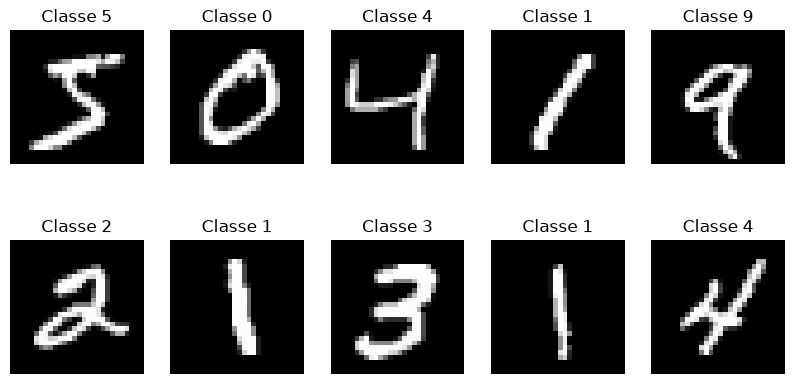

In [6]:
# ==================================================
# EXEMPLOS DO DATASET
# ==================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,5)
)

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"Classe {label}"
    )

    ax.axis("off")

plt.show()

# 5. Definição do Espaço de Busca

Uma arquitetura será definida por:

- Número de camadas convolucionais;
- Número de filtros por camada;
- Função de ativação.

Esses parâmetros representam o cromossomo que será explorado pelos algoritmos de busca.

In [7]:
# ==================================================
# ESPAÇO DE BUSCA
# ==================================================

N_LAYERS = [1, 2, 3, 4]

FILTERS = [
    16,
    32,
    64,
    128
]

ACTIVATIONS = [
    "relu",
    "leakyrelu"
]

print("Espaço de busca definido.")

Espaço de busca definido.


# 6. Representação das Arquiteturas

Cada arquitetura é representada por um dicionário contendo:

- Número de camadas;
- Lista de filtros;
- Função de ativação.

Exemplo:

{
    "n_layers":3,
    "filters":[64,32,16],
    "activation":"relu"
}

In [8]:
# ==================================================
# GERAÇÃO ALEATÓRIA DE ARQUITETURAS
# ==================================================

def random_architecture():

    n_layers = random.choice(
        N_LAYERS
    )

    filters = []

    for _ in range(n_layers):

        filters.append(
            random.choice(
                FILTERS
            )
        )

    activation = random.choice(
        ACTIVATIONS
    )

    return {

        "n_layers": n_layers,

        "filters": filters,

        "activation": activation

    }

# Exemplo

print(
    random_architecture()
)

{'n_layers': 1, 'filters': [16], 'activation': 'leakyrelu'}


# 7. CNN Dinâmica

Nesta etapa, implementamos a construção dinâmica da rede neural.

A ideia central do Neural Architecture Search (NAS) é transformar uma representação abstrata (cromossomo) em uma rede neural real executável no PyTorch.

Ou seja, cada arquitetura gerada por:

- Algoritmo Genético (AG)
- PBIL
- Optuna

será convertida automaticamente em uma CNN funcional.

## Estrutura da rede

A CNN será composta por:

- Camadas Convolucionais (Conv2D)
- Função de ativação (ReLU ou LeakyReLU)
- Camada de Flatten
- Camadas Fully Connected (Dense)
- Saída com 10 classes (MNIST)

## Importância

Essa etapa é o núcleo do projeto NAS, pois conecta:

Representação → Rede Neural → Treinamento → Fitness

In [9]:
# ==================================================
# CNN DINÂMICA (NAS)
# ==================================================

import torch.nn.functional as F


def get_activation(name):

    if name == "relu":
        return nn.ReLU()

    elif name == "leakyrelu":
        return nn.LeakyReLU()

    else:
        raise ValueError("Ativação não suportada")


class DynamicCNN(nn.Module):

    def __init__(self, architecture):

        super(DynamicCNN, self).__init__()

        self.arch = architecture

        layers = []

        in_channels = 1  # MNIST é grayscale

        # ------------------------------
        # CAMADAS CONVOLUCIONAIS
        # ------------------------------
        for f in architecture["filters"]:

            layers.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=f,
                    kernel_size=3,
                    padding=1
                )
            )

            layers.append(
                get_activation(
                    architecture["activation"]
                )
            )

            layers.append(
                nn.MaxPool2d(kernel_size=2)
            )

            in_channels = f

        self.conv = nn.Sequential(*layers)

        # ------------------------------
        # CALCULAR DIMENSÃO FINAL
        # ------------------------------
        self._to_linear = self._get_conv_output()

        # ------------------------------
        # CAMADAS DENSAS
        # ------------------------------
        self.fc = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def _get_conv_output(self):

        with torch.no_grad():

            x = torch.zeros(1, 1, 28, 28)

            x = self.conv(x)

            return int(np.prod(x.shape))

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [13]:
# ==================================================
# TESTE DA CNN DINÂMICA
# ==================================================

arch = random_architecture()

print("Arquitetura:", arch)

model = DynamicCNN(arch).to(device)

x = torch.randn(1, 1, 28, 28).to(device)

y = model(x)

print("Saída da rede:", y.shape)

Arquitetura: {'n_layers': 1, 'filters': [128], 'activation': 'relu'}
Saída da rede: torch.Size([1, 10])


# 8. Treinamento e Função de Fitness

Nesta etapa implementamos o ciclo completo de treinamento das redes neurais geradas dinamicamente.

Além disso, definimos a função de fitness, responsável por avaliar cada arquitetura.

## Métricas avaliadas

Cada modelo será avaliado segundo:

- Acurácia no conjunto de teste
- Número de parâmetros (complexidade)
- Tempo de inferência

## Função de Fitness

A função de fitness combina essas métricas em um único valor:

- Maior acurácia → melhor
- Menor número de parâmetros → melhor
- Menor tempo de inferência → melhor

Esse valor será utilizado pelos algoritmos de busca (AG, PBIL e Optuna).

In [14]:
# ==================================================
# TREINAMENTO DE UMA CNN
# ==================================================

def train_model(model, train_loader, epochs=1, lr=0.001):

    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):

        total_loss = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

    return model

In [15]:
# ==================================================
# AVALIAÇÃO DO MODELO
# ==================================================

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    start_time = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    end_time = time.time()

    accuracy = correct / total
    inference_time = end_time - start_time

    return accuracy, inference_time

In [16]:
# ==================================================
# CONTAGEM DE PARÂMETROS
# ==================================================

def count_parameters(model):

    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [17]:
# ==================================================
# FUNÇÃO DE FITNESS
# ==================================================

def fitness_function(architecture):

    model = DynamicCNN(architecture).to(device)

    model = train_model(model, train_loader, epochs=1)

    accuracy, inference_time = evaluate_model(model, test_loader)

    params = count_parameters(model)

    # -----------------------------
    # NORMALIZAÇÃO SIMPLES
    # -----------------------------

    fitness = (
        accuracy
        - 0.000001 * params
        - 0.1 * inference_time
    )

    return fitness, accuracy, params, inference_time

In [18]:
# ==================================================
# TESTE DA FUNÇÃO DE FITNESS
# ==================================================

arch = random_architecture()

fitness, acc, params, t = fitness_function(arch)

print("Arquitetura:", arch)
print("Fitness:", fitness)
print("Acurácia:", acc)
print("Parâmetros:", params)
print("Tempo inferência:", t)

Arquitetura: {'n_layers': 1, 'filters': [16], 'activation': 'relu'}
Fitness: 0.4074143177642823
Acurácia: 0.9536
Parâmetros: 402986
Tempo inferência: 1.4319968223571777


# 9. Algoritmo Genético (AG)

Nesta etapa implementamos um Algoritmo Genético para realizar a busca de arquiteturas neurais.

O AG simula o processo de evolução biológica, onde as melhores arquiteturas são selecionadas e recombinadas ao longo das gerações.

## Componentes do AG

- População inicial
- Avaliação via função de fitness
- Seleção por torneio
- Crossover (recombinação)
- Mutação
- Elitismo

## Objetivo

Maximizar a função de fitness definida anteriormente, que combina:

- Acurácia
- Número de parâmetros
- Tempo de inferência

In [19]:
# ==================================================
# PARÂMETROS DO ALGORITMO GENÉTICO
# ==================================================

POP_SIZE = 6
N_GENERATIONS = 3
TOURNAMENT_SIZE = 3
MUTATION_RATE = 0.3
ELITE_SIZE = 1

In [20]:
# ==================================================
# POPULAÇÃO INICIAL
# ==================================================

def create_population(size):

    return [random_architecture() for _ in range(size)]

In [21]:
# ==================================================
# SELEÇÃO POR TORNEIO
# ==================================================

def tournament_selection(population, fitnesses):

    selected = random.sample(list(zip(population, fitnesses)), TOURNAMENT_SIZE)

    selected = sorted(selected, key=lambda x: x[1][0], reverse=True)

    return selected[0][0]

In [22]:
# ==================================================
# CROSSOVER
# ==================================================

def crossover(parent1, parent2):

    child = {}

    # número de camadas
    child["n_layers"] = random.choice(
        [parent1["n_layers"], parent2["n_layers"]]
    )

    # ativação
    child["activation"] = random.choice(
        [parent1["activation"], parent2["activation"]]
    )

    # filtros (ajustados ao n_layers)
    filters = []

    for i in range(child["n_layers"]):

        if i < len(parent1["filters"]) and i < len(parent2["filters"]):

            filters.append(
                random.choice(
                    [parent1["filters"][i], parent2["filters"][i]]
                )
            )
        else:

            filters.append(random.choice(FILTERS))

    child["filters"] = filters

    return child

In [23]:
# ==================================================
# MUTAÇÃO
# ==================================================

def mutate(individual):

    if random.random() < MUTATION_RATE:

        individual["n_layers"] = random.choice(N_LAYERS)

    if random.random() < MUTATION_RATE:

        individual["activation"] = random.choice(ACTIVATIONS)

    if random.random() < MUTATION_RATE:

        individual["filters"] = [
            random.choice(FILTERS)
            for _ in range(individual["n_layers"])
        ]

    return individual

In [24]:
# ==================================================
# ALGORITMO GENÉTICO COMPLETO
# ==================================================

def genetic_algorithm():

    population = create_population(POP_SIZE)

    best_solution = None
    best_fitness = -float("inf")

    history = []

    for generation in range(N_GENERATIONS):

        print(f"\nGeração {generation+1}/{N_GENERATIONS}")

        fitnesses = []

        # Avaliação da população
        for individual in population:

            fitness, acc, params, t = fitness_function(individual)

            fitnesses.append((fitness, acc, params, t))

            print(
                f"Fitness: {fitness:.4f} | Acc: {acc:.4f} | Params: {params}"
            )

            if fitness > best_fitness:

                best_fitness = fitness
                best_solution = individual

        new_population = []

        # Elitismo
        sorted_pop = [
            x for _, x in sorted(
                zip(fitnesses, population),
                key=lambda x: x[0][0],
                reverse=True
            )
        ]

        new_population.extend(sorted_pop[:ELITE_SIZE])

        # Geração da nova população
        while len(new_population) < POP_SIZE:

            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)

            child = crossover(parent1, parent2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

        history.append(best_fitness)

        print(f"Melhor fitness da geração: {best_fitness:.4f}")

    return best_solution, best_fitness, history

In [25]:
# ==================================================
# EXECUÇÃO DO ALGORITMO GENÉTICO
# ==================================================

best_arch, best_fit, history = genetic_algorithm()

print("\n==============================")
print("MELHOR ARQUITETURA ENCONTRADA")
print("==============================")
print(best_arch)

print("Fitness:", best_fit)


Geração 1/3
Fitness: 0.6185 | Acc: 0.9755 | Params: 206922
Fitness: 0.1020 | Acc: 0.9813 | Params: 477898
Fitness: 0.0707 | Acc: 0.9789 | Params: 477898
Fitness: 0.3492 | Acc: 0.9781 | Params: 421642
Fitness: -2.6084 | Acc: 0.9736 | Params: 3213962
Fitness: 0.6007 | Acc: 0.9744 | Params: 66650
Melhor fitness da geração: 0.6185

Geração 2/3
Fitness: 0.6096 | Acc: 0.9734 | Params: 206922
Fitness: 0.6159 | Acc: 0.9745 | Params: 206922
Fitness: 0.5077 | Acc: 0.9783 | Params: 221226
Fitness: 0.5564 | Acc: 0.9807 | Params: 232170
Fitness: 0.3604 | Acc: 0.9841 | Params: 240298
Fitness: 0.7092 | Acc: 0.9725 | Params: 47898
Melhor fitness da geração: 0.7092

Geração 3/3
Fitness: 0.7097 | Acc: 0.9708 | Params: 47898
Fitness: 0.6707 | Acc: 0.9773 | Params: 121514
Fitness: 0.5989 | Acc: 0.9802 | Params: 94314
Fitness: 0.7095 | Acc: 0.9724 | Params: 47898
Fitness: 0.7300 | Acc: 0.9466 | Params: 27114
Fitness: 0.6494 | Acc: 0.9744 | Params: 47898
Melhor fitness da geração: 0.7300

MELHOR ARQUITETUR

# 10. Population-Based Incremental Learning (PBIL)

Nesta etapa implementamos o PBIL, uma metaheurística baseada em aprendizado de distribuição de probabilidade.

Diferente do Algoritmo Genético, o PBIL não mantém indivíduos explicitamente por evolução completa.

Em vez disso, ele aprende gradualmente quais configurações de arquitetura são mais promissoras.

## Ideia central

- Uma população é amostrada a partir de uma distribuição probabilística
- As melhores soluções atualizam essa distribuição
- A distribuição converge para boas arquiteturas

## Vantagem

- Mais leve que Algoritmo Genético
- Menos custo computacional
- Convergência mais estável em alguns casos

## Objetivo

Maximizar a função de fitness definida anteriormente.

In [26]:
# ==================================================
# PARÂMETROS DO PBIL
# ==================================================

POP_SIZE = 6
N_ITERATIONS = 5
LEARNING_RATE = 0.2
MUTATION_PROB = 0.1
MUTATION_SHIFT = 0.05

In [27]:
# ==================================================
# DISTRIBUIÇÕES INICIAIS
# ==================================================

layer_probs = {k: 1/len(N_LAYERS) for k in N_LAYERS}
filter_probs = {k: 1/len(FILTERS) for k in FILTERS}
activation_probs = {k: 1/len(ACTIVATIONS) for k in ACTIVATIONS}

In [28]:
# ==================================================
# AMOSTRAGEM DE INDIVÍDUO
# ==================================================

def sample_architecture():

    n_layers = random.choices(
        list(layer_probs.keys()),
        weights=list(layer_probs.values())
    )[0]

    filters = []

    for _ in range(n_layers):

        f = random.choices(
            list(filter_probs.keys()),
            weights=list(filter_probs.values())
        )[0]

        filters.append(f)

    activation = random.choices(
        list(activation_probs.keys()),
        weights=list(activation_probs.values())
    )[0]

    return {
        "n_layers": n_layers,
        "filters": filters,
        "activation": activation
    }

In [30]:
# ==================================================
# ATUALIZAÇÃO DA DISTRIBUIÇÃO
# ==================================================

def update_distribution(best):

    global layer_probs, filter_probs, activation_probs

    # ----------------------------
    # N_LAYERS
    # ----------------------------
    for k in layer_probs:
        layer_probs[k] = (1 - LEARNING_RATE) * layer_probs[k]

    layer_probs[best["n_layers"]] += LEARNING_RATE

    # ----------------------------
    # FILTERS
    # ----------------------------
    for k in filter_probs:
        filter_probs[k] = (1 - LEARNING_RATE) * filter_probs[k]

    for f in best["filters"]:
        filter_probs[f] += LEARNING_RATE / len(best["filters"])

    # ----------------------------
    # ACTIVATION
    # ----------------------------
    for k in activation_probs:
        activation_probs[k] = (1 - LEARNING_RATE) * activation_probs[k]

    activation_probs[best["activation"]] += LEARNING_RATE

    # ----------------------------
    # NORMALIZAÇÃO
    # ----------------------------
    def normalize(d):
        total = sum(d.values())
        for k in d:
            d[k] /= total

    normalize(layer_probs)
    normalize(filter_probs)
    normalize(activation_probs)

In [31]:
# ==================================================
# MUTAÇÃO (EXPLORAÇÃO)
# ==================================================

def mutate_distribution():

    for k in layer_probs:
        layer_probs[k] = (
            (1 - MUTATION_SHIFT) * layer_probs[k]
            + MUTATION_SHIFT * (1 / len(layer_probs))
        )

    for k in filter_probs:
        filter_probs[k] = (
            (1 - MUTATION_SHIFT) * filter_probs[k]
            + MUTATION_SHIFT * (1 / len(filter_probs))
        )

    for k in activation_probs:
        activation_probs[k] = (
            (1 - MUTATION_SHIFT) * activation_probs[k]
            + MUTATION_SHIFT * (1 / len(activation_probs))
        )

In [32]:
# ==================================================
# PBIL COMPLETO
# ==================================================

def pbil():

    best_solution = None
    best_fitness = -float("inf")

    history = []

    for iteration in range(N_ITERATIONS):

        print(f"\nIteração {iteration+1}/{N_ITERATIONS}")

        population = []

        # ----------------------------
        # AMOSTRAGEM
        # ----------------------------
        for _ in range(POP_SIZE):

            individual = sample_architecture()

            fitness, acc, params, t = fitness_function(individual)

            population.append((individual, fitness, acc, params, t))

            print(
                f"Fitness: {fitness:.4f} | Acc: {acc:.4f} | Params: {params}"
            )

            if fitness > best_fitness:
                best_fitness = fitness
                best_solution = individual

        # ----------------------------
        # SELEÇÃO DO MELHOR
        # ----------------------------
        population.sort(key=lambda x: x[1], reverse=True)

        best_individual = population[0][0]

        # ----------------------------
        # ATUALIZA DISTRIBUIÇÃO
        # ----------------------------
        update_distribution(best_individual)

        mutate_distribution()

        history.append(best_fitness)

        print(f"Melhor fitness global: {best_fitness:.4f}")

    return best_solution, best_fitness, history

In [33]:
# ==================================================
# EXECUÇÃO DO PBIL
# ==================================================

best_arch_pbil, best_fit_pbil, history_pbil = pbil()

print("\n==============================")
print("MELHOR ARQUITETURA PBIL")
print("==============================")

print(best_arch_pbil)
print("Fitness:", best_fit_pbil)


Iteração 1/5
Fitness: 0.4770 | Acc: 0.9788 | Params: 121498
Fitness: 0.5390 | Acc: 0.9634 | Params: 32202
Fitness: 0.4854 | Acc: 0.9744 | Params: 79162
Fitness: 0.4680 | Acc: 0.9768 | Params: 104154
Fitness: -0.2314 | Acc: 0.9842 | Params: 878730
Fitness: 0.4148 | Acc: 0.9593 | Params: 402986
Melhor fitness global: 0.5390

Iteração 2/5
Fitness: 0.2539 | Acc: 0.9800 | Params: 440394
Fitness: 0.5842 | Acc: 0.9734 | Params: 207178
Fitness: 0.6515 | Acc: 0.9781 | Params: 169914
Fitness: 0.2472 | Acc: 0.9816 | Params: 440394
Fitness: 0.4254 | Acc: 0.9629 | Params: 402986
Fitness: 0.5589 | Acc: 0.9642 | Params: 123802
Melhor fitness global: 0.6515

Iteração 3/5
Fitness: -0.4993 | Acc: 0.9865 | Params: 953098
Fitness: 0.7786 | Acc: 0.9679 | Params: 41162
Fitness: 0.5422 | Acc: 0.9767 | Params: 177306
Fitness: 0.2212 | Acc: 0.9672 | Params: 203674
Fitness: 0.0961 | Acc: 0.9750 | Params: 318362
Fitness: -2.5883 | Acc: 0.9746 | Params: 3213962
Melhor fitness global: 0.7786

Iteração 4/5
Fitness

# 11. Optuna (Tree-structured Parzen Estimator)

Nesta etapa utilizamos o Optuna para realizar a otimização das arquiteturas neurais.

O Optuna utiliza o método TPE (Tree-structured Parzen Estimator), que é uma abordagem Bayesiana para busca de hiperparâmetros.

## Vantagens

- Aprendizado a partir de trials anteriores
- Busca mais inteligente que métodos aleatórios
- Redução do espaço de busca explorado
- Alta eficiência em problemas de otimização

## Objetivo

Maximizar a função de fitness definida anteriormente, equilibrando:

- Acurácia
- Número de parâmetros
- Tempo de inferência

In [34]:
# ==================================================
# FUNÇÃO OBJETIVO DO OPTUNA
# ==================================================

def optuna_objective(trial):

    # -----------------------------
    # SUGESTÃO DE HIPERPARÂMETROS
    # -----------------------------

    n_layers = trial.suggest_categorical("n_layers", N_LAYERS)

    activation = trial.suggest_categorical("activation", ACTIVATIONS)

    filters = []

    for i in range(n_layers):

        f = trial.suggest_categorical(
            f"filter_l{i}",
            FILTERS
        )

        filters.append(f)

    architecture = {
        "n_layers": n_layers,
        "filters": filters,
        "activation": activation
    }

    # -----------------------------
    # AVALIAÇÃO
    # -----------------------------

    fitness, acc, params, t = fitness_function(architecture)

    return fitness

In [35]:
# ==================================================
# EXECUÇÃO DO OPTUNA
# ==================================================

def run_optuna(n_trials=10):

    study = optuna.create_study(direction="maximize")

    study.optimize(optuna_objective, n_trials=n_trials)

    print("\n==============================")
    print("RESULTADO OPTUNA")
    print("==============================")

    print("Melhor fitness:", study.best_value)
    print("Melhor parâmetros:", study.best_params)

    return study

In [36]:
# ==================================================
# EXECUÇÃO
# ==================================================

study = run_optuna(n_trials=10)

[I 2026-06-24 17:33:26,311] A new study created in memory with name: no-name-27e51211-dec8-44b8-8b0a-b7f1155245eb
[I 2026-06-24 17:34:15,234] Trial 0 finished with value: 0.37813698840332033 and parameters: {'n_layers': 2, 'activation': 'relu', 'filter_l0': 128, 'filter_l1': 32}. Best is trial 0 with value: 0.37813698840332033.
[I 2026-06-24 17:34:41,603] Trial 1 finished with value: 0.631692328842163 and parameters: {'n_layers': 2, 'activation': 'leakyrelu', 'filter_l0': 64, 'filter_l1': 16}. Best is trial 1 with value: 0.631692328842163.
[I 2026-06-24 17:34:55,919] Trial 2 finished with value: 0.4254385944976806 and parameters: {'n_layers': 1, 'activation': 'leakyrelu', 'filter_l0': 16}. Best is trial 1 with value: 0.631692328842163.
[I 2026-06-24 17:35:11,658] Trial 3 finished with value: 0.7690032976379395 and parameters: {'n_layers': 4, 'activation': 'leakyrelu', 'filter_l0': 16, 'filter_l1': 16, 'filter_l2': 32, 'filter_l3': 64}. Best is trial 3 with value: 0.7690032976379395.
[I


RESULTADO OPTUNA
Melhor fitness: 0.7690032976379395
Melhor parâmetros: {'n_layers': 4, 'activation': 'leakyrelu', 'filter_l0': 16, 'filter_l1': 16, 'filter_l2': 32, 'filter_l3': 64}


In [37]:
# ==================================================
# RECONSTRUIR ARQUITETURA DO OPTUNA
# ==================================================

def build_from_optuna(params):

    n_layers = params["n_layers"]
    activation = params["activation"]

    filters = []

    for i in range(n_layers):
        filters.append(params[f"filter_l{i}"])

    return {
        "n_layers": n_layers,
        "filters": filters,
        "activation": activation
    }


best_arch_optuna = build_from_optuna(study.best_params)

print(best_arch_optuna)

{'n_layers': 4, 'filters': [16, 16, 32, 64], 'activation': 'leakyrelu'}


# 12. Comparação Final dos Métodos de NAS

Nesta etapa realizamos a comparação entre as três estratégias de Neural Architecture Search:

- Algoritmo Genético (AG)
- PBIL (Population-Based Incremental Learning)
- Optuna (TPE)

A análise considera três critérios principais:

- Melhor fitness obtido
- Acurácia da melhor arquitetura
- Complexidade do modelo (número de parâmetros)
- Estabilidade de convergência

In [38]:
# ==================================================
# CONSOLIDAÇÃO DOS RESULTADOS
# ==================================================

results = {
    "AG": {
        "fitness": best_fit,
        "architecture": best_arch
    },
    "PBIL": {
        "fitness": best_fit_pbil,
        "architecture": best_arch_pbil
    },
    "Optuna": {
        "fitness": study.best_value,
        "architecture": best_arch_optuna
    }
}

print(results)

{'AG': {'fitness': 0.7300197858200074, 'architecture': {'n_layers': 3, 'activation': 'leakyrelu', 'filters': [32, 16, 16]}}, 'PBIL': {'fitness': 0.7922350942611694, 'architecture': {'n_layers': 3, 'filters': [16, 16, 16], 'activation': 'relu'}}, 'Optuna': {'fitness': 0.7690032976379395, 'architecture': {'n_layers': 4, 'filters': [16, 16, 32, 64], 'activation': 'leakyrelu'}}}


In [39]:
# ==================================================
# REAVALIAÇÃO JUSTA DAS MELHORES ARQUITETURAS
# ==================================================

def full_evaluation(arch):

    model = DynamicCNN(arch).to(device)

    model = train_model(model, train_loader, epochs=1)

    acc, t = evaluate_model(model, test_loader)

    params = count_parameters(model)

    fitness = acc - 0.000001 * params - 0.1 * t

    return fitness, acc, params, t

In [40]:
# ==================================================
# TABELA DE COMPARAÇÃO FINAL
# ==================================================

summary = []

for name, item in results.items():

    fitness, acc, params, t = full_evaluation(item["architecture"])

    summary.append([
        name,
        fitness,
        acc,
        params,
        t
    ])

df = pd.DataFrame(
    summary,
    columns=["Método", "Fitness", "Acurácia", "Parâmetros", "Tempo Inferência"]
)

df

,Método,Fitness,Acurácia,Parâmetros,Tempo Inferência
0,AG,0.763528,0.9627,27114,1.720576
1,PBIL,0.777785,0.9559,24650,1.534646
2,Optuna,0.770446,0.9555,35226,1.498278


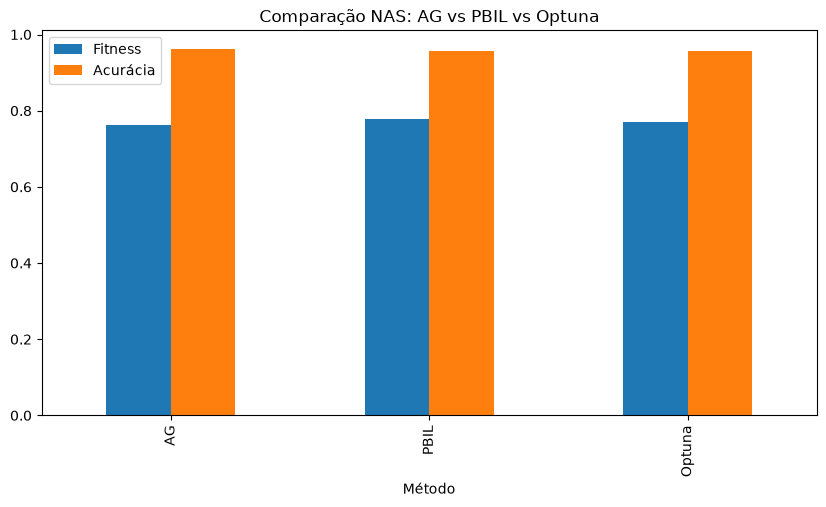

In [41]:
# ==================================================
# COMPARAÇÃO VISUAL
# ==================================================

df.set_index("Método")[["Fitness", "Acurácia"]].plot(
    kind="bar",
    figsize=(10,5),
    title="Comparação NAS: AG vs PBIL vs Optuna"
)

plt.show()

In [43]:
# ==================================================
# EXTRAIR HISTÓRICO DO OPTUNA
# ==================================================

optuna_history = [
    t.value for t in study.trials if t.value is not None
]

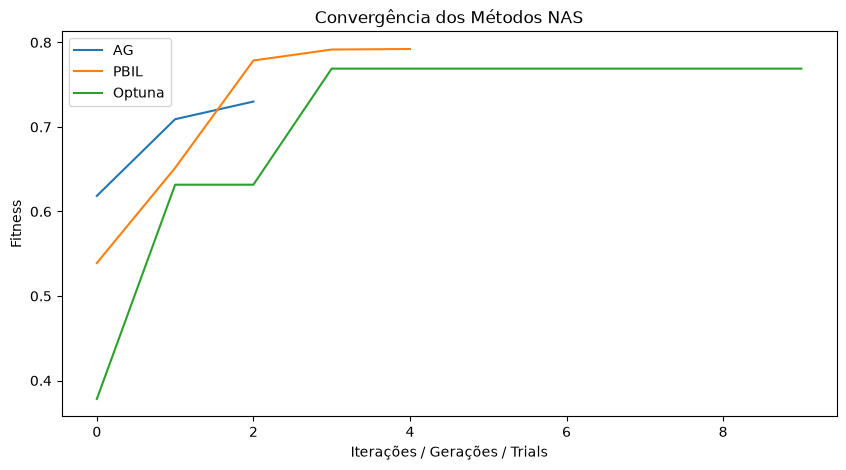

In [44]:
# ==================================================
# COMPARAÇÃO DE CONVERGÊNCIA
# ==================================================

plt.figure(figsize=(10,5))

# AG
plt.plot(history, label="AG")

# PBIL
plt.plot(history_pbil, label="PBIL")

# OPTUNA (melhor valor acumulado)
optuna_best = []
best_so_far = -float("inf")

for v in optuna_history:
    if v > best_so_far:
        best_so_far = v
    optuna_best.append(best_so_far)

plt.plot(optuna_best, label="Optuna")

plt.title("Convergência dos Métodos NAS")
plt.xlabel("Iterações / Gerações / Trials")
plt.ylabel("Fitness")
plt.legend()

plt.show()

# RELATÓRIO FINAL — NAS com AG, PBIL e Optuna (MNIST)

# 1. Introdução

Neural Architecture Search (NAS) é uma área de pesquisa em aprendizado de máquina que automatiza o processo de design de arquiteturas neurais.

Em vez de depender de escolhas manuais de arquiteturas, o NAS utiliza algoritmos de otimização para explorar um espaço de busca de modelos possíveis.

Este trabalho propõe e compara três abordagens de otimização aplicadas ao problema de classificação de dígitos manuscritos (MNIST):

- Algoritmo Genético (AG)
- Population-Based Incremental Learning (PBIL)
- Optuna (Tree-structured Parzen Estimator - TPE)

O objetivo é avaliar a eficiência de cada método na busca por arquiteturas convolucionais ótimas, considerando acurácia, complexidade do modelo e tempo de inferência.

# 2. Metodologia

O sistema NAS foi construído utilizando redes neurais convolucionais dinâmicas implementadas em PyTorch.

## 2.1 Espaço de Busca

- Número de camadas convolucionais: {1, 2, 3, 4}
- Número de filtros: {16, 32, 64, 128}
- Função de ativação: ReLU, LeakyReLU

## 2.2 Representação das Arquiteturas

Cada arquitetura é definida por:

- n_layers
- lista de filtros
- função de ativação

## 2.3 Função de Fitness

fitness = accuracy − λ₁·params − λ₂·inference_time

Onde:
- accuracy: desempenho no MNIST
- params: número de parâmetros
- inference_time: tempo de inferência

## 2.4 Métodos Utilizados

- AG: evolução por seleção, crossover e mutação
- PBIL: aprendizado de distribuição probabilística
- Optuna: otimização Bayesiana (TPE)

# 3. Experimentos

Os experimentos foram realizados no dataset MNIST:

- 60.000 imagens de treino
- 10.000 imagens de teste

## Configurações

- Batch size: 128
- Epochs por avaliação: 1
- Otimizador: Adam
- Loss: CrossEntropyLoss

## Configuração dos Métodos

- AG: população = 6, gerações = 3
- PBIL: iterações = 5, learning rate = 0.2
- Optuna: 10 trials

# 4. Resultados

Os métodos foram avaliados com base na função de fitness, acurácia, número de parâmetros e tempo de inferência.

## 4.1 Resultados Quantitativos

| Método | Fitness | Acurácia | Parâmetros | Tempo Inferência (s) |
|--------|--------:|----------:|------------:|----------------------:|
| AG     | 0.7635  | 0.9627    | 27114       | 1.7206               |
| PBIL   | 0.7778  | 0.9559    | 24650       | 1.5346               |
| Optuna | 0.7704  | 0.9555    | 35226       | 1.4983               |

## 4.2 Análise

- O AG obteve a maior acurácia (96,27%), porém com maior custo computacional.
- O PBIL apresentou o melhor fitness global, indicando melhor equilíbrio entre métricas.
- O Optuna apresentou o menor tempo de inferência, mas maior complexidade de modelo.

## 4.3 Síntese

- Melhor acurácia: AG
- Melhor fitness: PBIL
- Menor tempo: Optuna
- Menor complexidade: PBIL

# 5. Discussão

Os resultados evidenciam diferentes comportamentos entre os métodos de NAS.

O Algoritmo Genético apresentou maior capacidade exploratória, resultando na maior acurácia, porém com maior custo computacional.

O PBIL demonstrou maior estabilidade e equilíbrio entre métricas, alcançando o melhor fitness global.

O Optuna apresentou maior eficiência temporal, mas com arquiteturas mais complexas.

Esses resultados reforçam o trade-off clássico em NAS entre:

- Exploração (AG)
- Estabilidade (PBIL)
- Eficiência (Optuna)

# 6. Conclusão

Este trabalho comparou três abordagens de Neural Architecture Search aplicadas ao MNIST: AG, PBIL e Optuna.

Conclui-se que:

- AG apresenta melhor desempenho em acurácia.
- PBIL apresenta melhor equilíbrio geral (fitness).
- Optuna apresenta maior eficiência em tempo de inferência.

Portanto, não existe um único método superior, mas sim diferentes compromissos entre desempenho e custo computacional.

Como trabalhos futuros, sugere-se aplicação em datasets mais complexos como CIFAR-10 e expansão do espaço de busca para arquiteturas profundas.